In [ ]:
%cd ..

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
import duckdb
import pandas as pd
from torchvision.transforms import transforms
from tqdm import tqdm
from project.models import EDMMauMau, EDMSerie
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE
from project.util.filters import MedianFilter

In [ ]:
GAME = "SpaceInvaders"
PATH = os.path.join("..", "checkpoints", "diff", f"{GAME}.pt")
DATA = os.path.join("..", "checkpoints", "memory", f"{GAME}.pt")
OUTPUT = os.path.join("..", "results", "denoising", f"denoise_{GAME}.svg")
N = 8
SIGMA_NOISE_START = 0.1
SIGMA_NOISE_END = 1
SAMPLES = 100

In [ ]:
plt.style.use(['science','no-latex', 'ieee'])

In [ ]:
device = "cuda:0"

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [48]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [49]:
psnrs_naive = torch.zeros((10, SAMPLES))
psnrs_full= torch.zeros_like(psnrs_naive)
psnrs_median = torch.zeros_like(psnrs_naive)

mses_naive = torch.zeros_like(psnrs_naive)
mses_full = torch.zeros_like(psnrs_naive)
mses_median = torch.zeros_like(psnrs_naive)

x = torch.zeros((SAMPLES, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(500_000)[:SAMPLES]):
    x[i] = data[img].to(device)

sigmas = torch.arange(SIGMA_NOISE_START, SIGMA_NOISE_END + 0.1, 0.1)

model_full = EDMSerie.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START, N=N).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START).to(device)

filter = MedianFilter()

for i, sigma in enumerate(sigmas):

    model_full.set_sigma_noise(sigma)
    model_naive.set_sigma_noise(sigma)

    e = sigma * torch.randn_like(x)
    x_noisy = x + e

    with torch.no_grad():

        x_denoised_full = model_full.denoise(x_noisy)
        x_denoised_naive = model_naive.denoise(x_noisy)
        x_denoised_median = filter.denoise(x_noisy.to("cpu"))

        for j in tqdm(range(SAMPLES), desc="samples"):

            psnrs_full[i, j] = PSNR(x[j].to("cpu"), x_denoised_full[j].to("cpu"), torch.tensor(2).to("cpu"))
            psnrs_naive[i, j] = PSNR(x[j].to("cpu"), x_denoised_naive[j].to("cpu"), torch.tensor(2).to("cpu"))
            psnrs_median[i, j] = PSNR(x[j].to("cpu"), x_denoised_median[j].to("cpu"), torch.tensor(2).to("cpu"))

            mses_full[i, j] = MSE(x[j].to("cpu"), x_denoised_full[j].to("cpu"))
            mses_naive[i, j] = MSE(x[j].to("cpu"), x_denoised_naive[j].to("cpu"))
            mses_median[i, j] = MSE(x[j].to("cpu"), x_denoised_median[j].to("cpu"))

samples: 100%|██████████| 100/100 [00:00<00:00, 591.13it/s]


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


torch.Size([10]) torch.Size([10, 100])


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


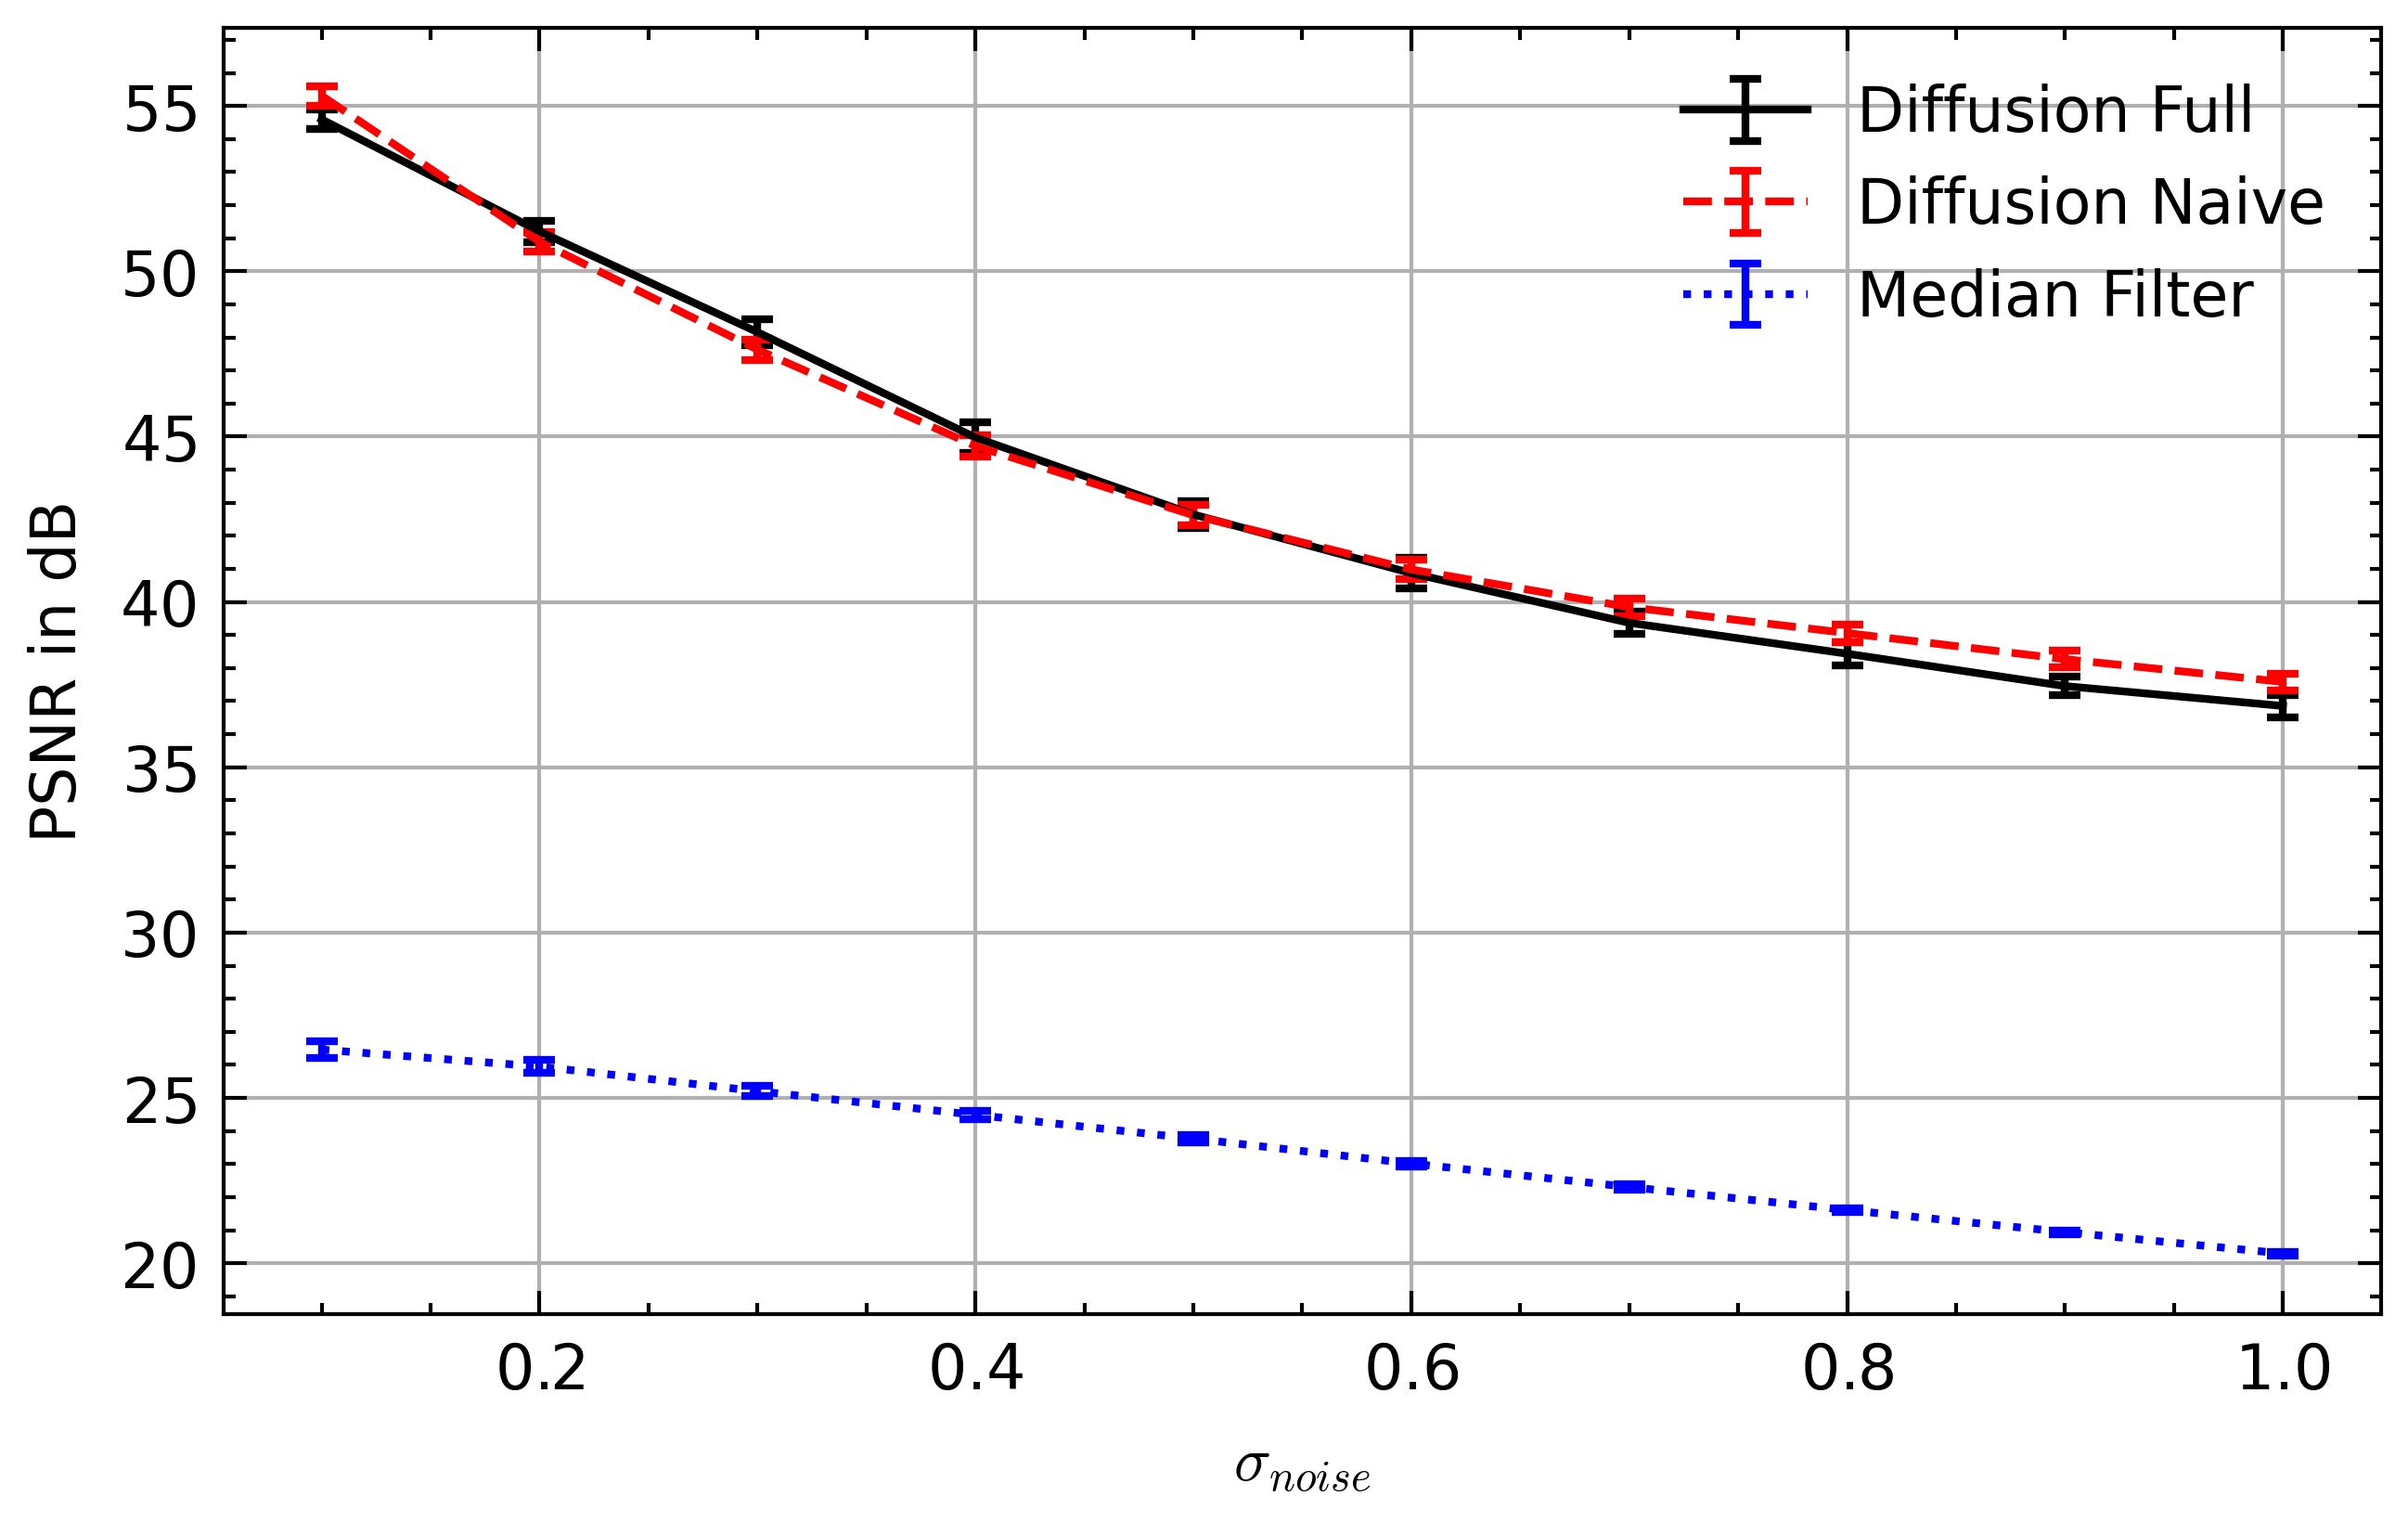

In [50]:
Ns = torch.arange(2, 33)

print(sigmas.shape, psnrs_full.shape)

plt.figure(figsize=(5, 3))

plt.errorbar(
    sigmas, 
    psnrs_full.mean(axis=1), 
    psnrs_full.std(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Full",
    capsize=2,
)
plt.errorbar(
    sigmas, 
    psnrs_naive.mean(axis=1), 
    psnrs_naive.std(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Naive",
    capsize=2,
)
plt.errorbar(
    sigmas, 
    psnrs_median.mean(axis=1), 
    psnrs_median.std(axis=1) / SAMPLES ** 0.5,
    label="Median Filter",
    capsize=2,
)
plt.xlabel("$\\sigma_{noise}$")
plt.ylabel("PSNR in dB")
plt.grid()
plt.legend()

plt.savefig(f"../results/denoising/psnr_{GAME}.svg")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


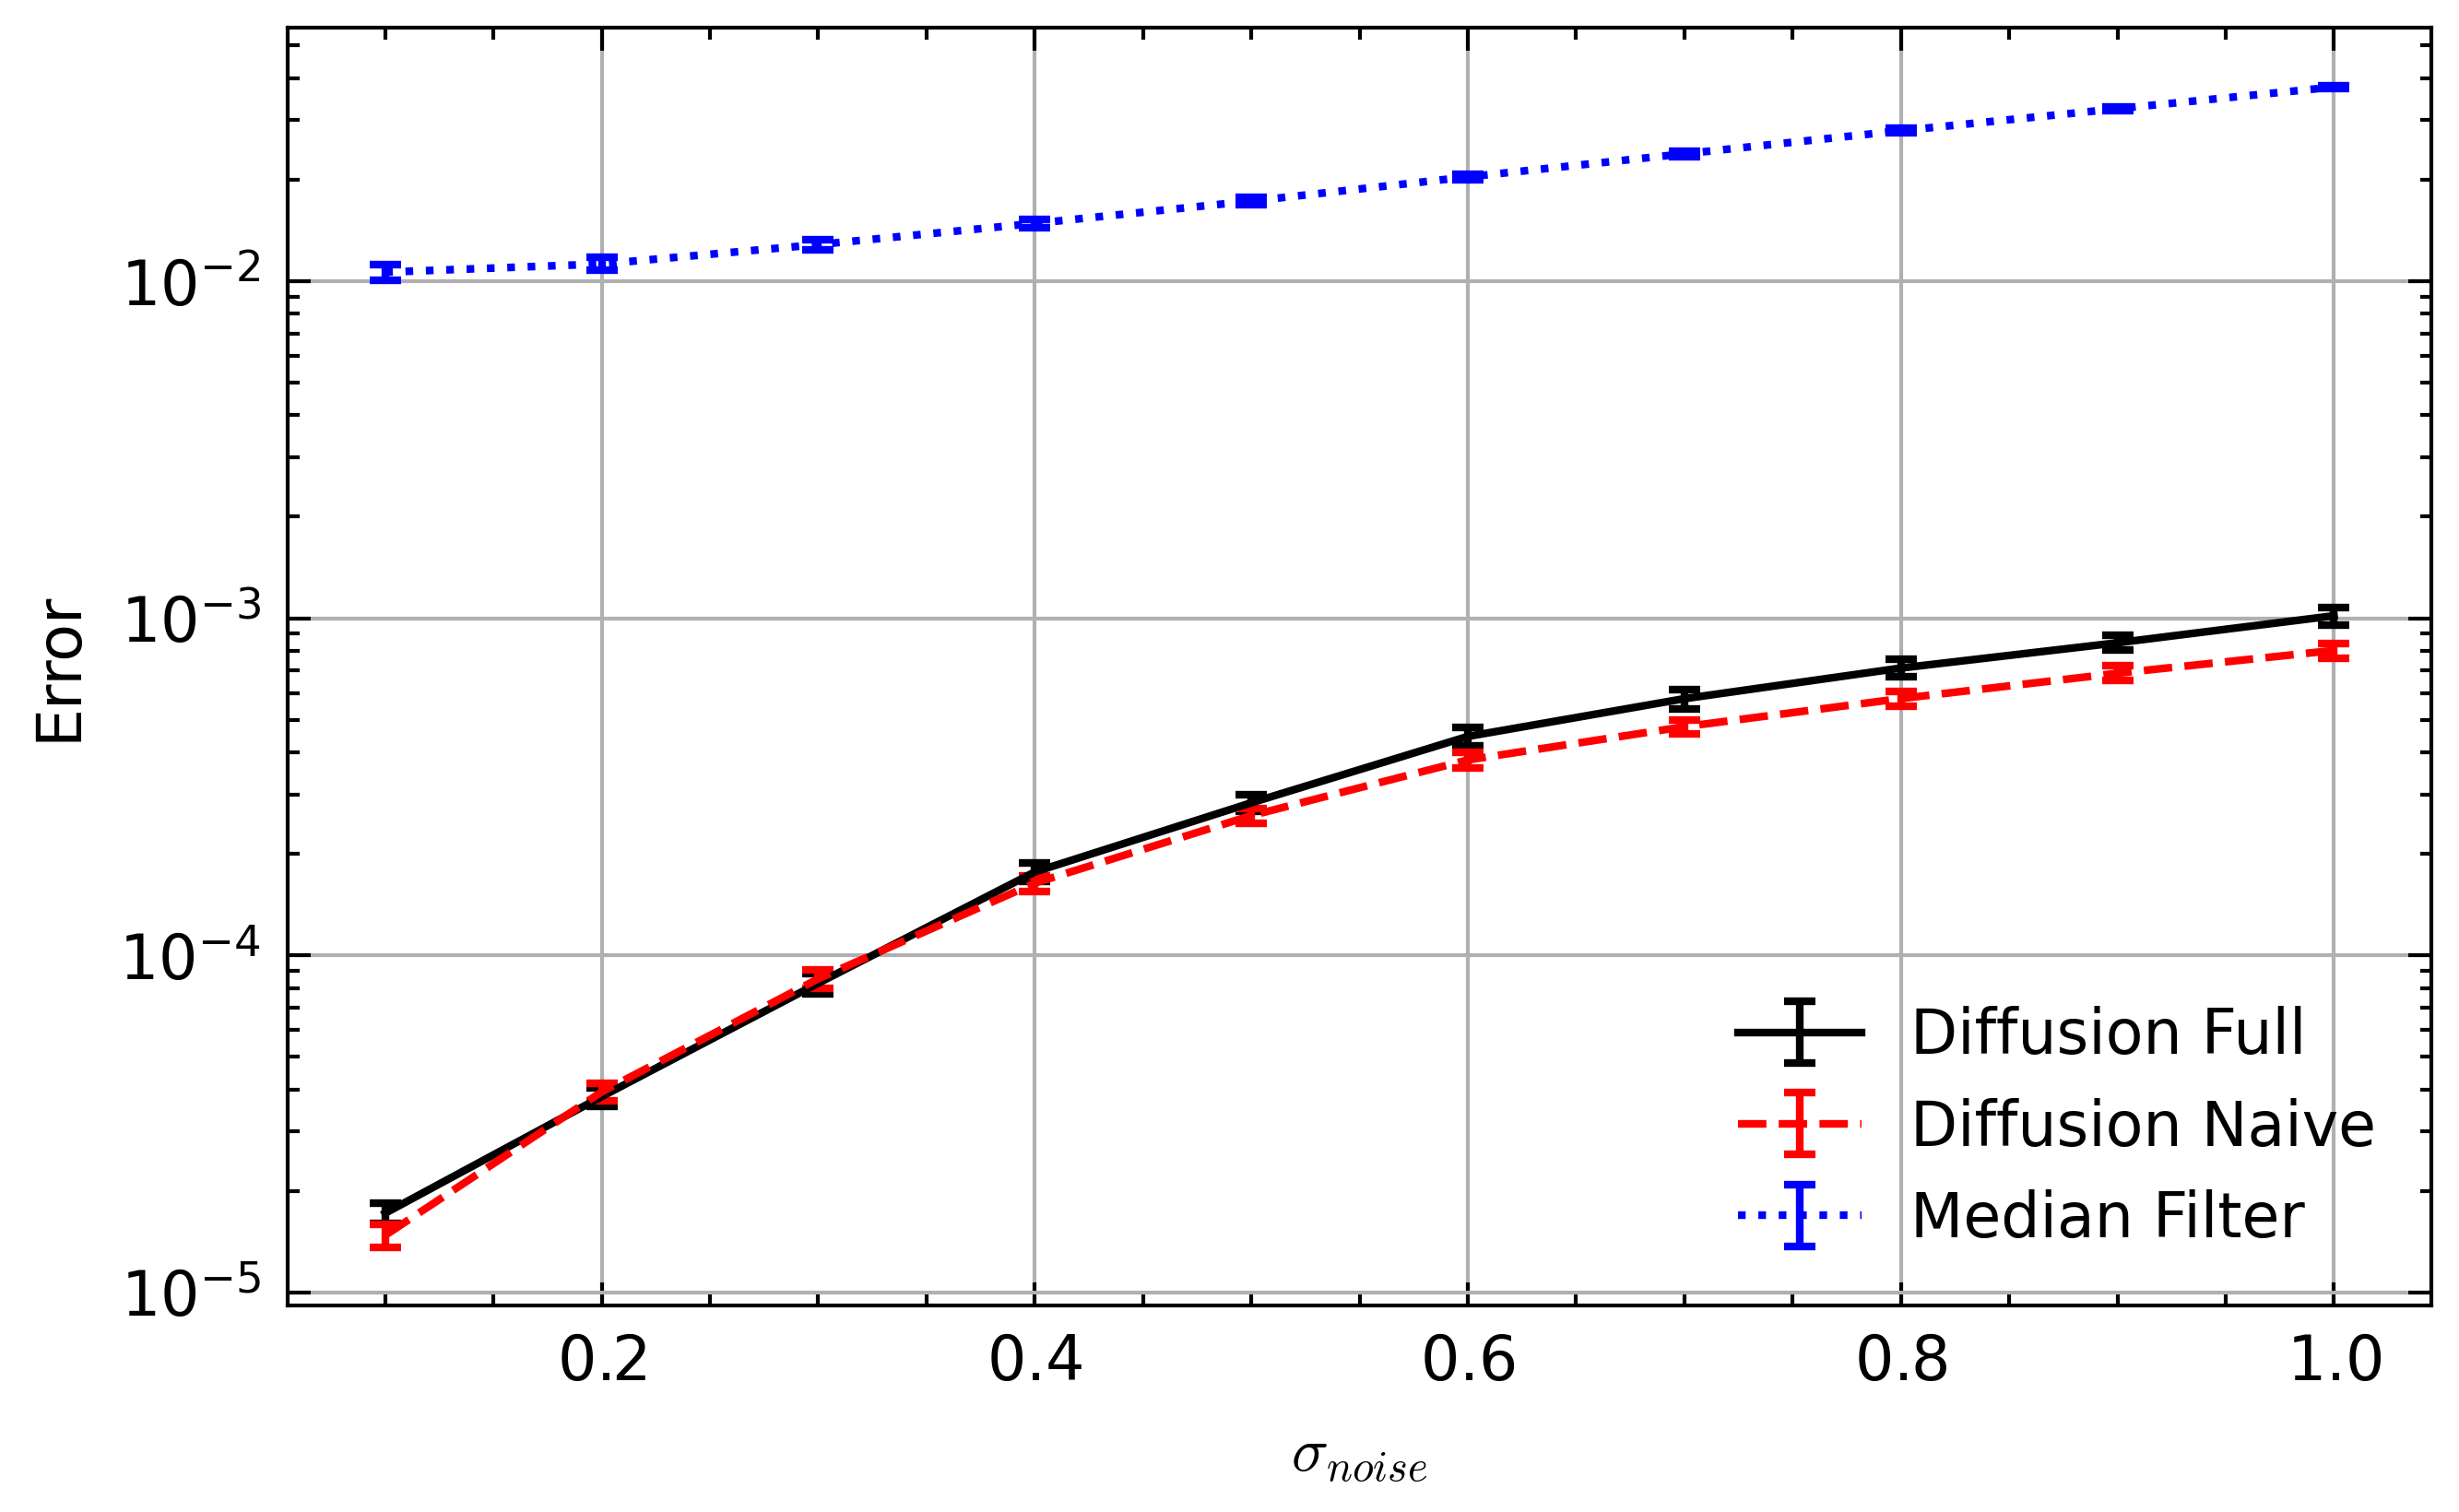

In [51]:
plt.figure(figsize=(5, 3))

plt.errorbar(
    sigmas, 
    mses_full.mean(axis=1), 
    mses_full.std(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Full",
    capsize=2,
)
plt.errorbar(
    sigmas, 
    mses_naive.mean(axis=1), 
    mses_naive.std(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Naive",
    capsize=2,
)
plt.errorbar(
    sigmas, 
    mses_median.mean(axis=1), 
    mses_median.std(axis=1) / SAMPLES ** 0.5,
    label="Median Filter",
    capsize=2,
)
plt.yscale("log")

plt.xlabel("$\\sigma_{noise}$")
plt.ylabel("Error")
plt.grid()
plt.legend()

plt.savefig(f"../results/denoising/mse_{GAME}.svg")
plt.show()

In [52]:
def mes(values):
    return values.std() / SAMPLES ** 0.5

def format_row(values):
    return f"{values.mean():.1f} ±{mes(values):.2f}"

In [53]:
s = [round(s.item(), 1) for s in sigmas]

data_median = {s[i]: format_row(values) for i, values in enumerate(psnrs_median)}
data_naive = {s[i]: format_row(values) for i, values in enumerate(psnrs_naive)}
data_full = {s[i]: format_row(values) for i, values in enumerate(psnrs_full)}

print(data_median)

data_df = {k: [v] + [data_naive[k]] + [data_full[k]] for k, v in data_median.items()}
data_df["setup"] = ["Median", "Diff (Naive)", "Diff (Full)"]

df = pd.DataFrame(data_df)
df.to_csv(f"../results/denoising/psnr_{GAME}.csv")

{0.1: '26.5 ±0.26', 0.2: '25.9 ±0.20', 0.3: '25.2 ±0.15', 0.4: '24.5 ±0.12', 0.5: '23.8 ±0.10', 0.6: '23.0 ±0.09', 0.7: '22.3 ±0.07', 0.8: '21.6 ±0.06', 0.9: '20.9 ±0.06', 1.0: '20.3 ±0.05'}
